## Extracción de los datos

In [1]:
import requests
import json

# URL de ubicación de los datos
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

# Solicitud de los datos
response = requests.get(url)

# Convertir los datos a JSON
data = response.json()


In [4]:
import pandas as pd

# Convertir los datos JSON a un DataFrame
df = pd.DataFrame(data)

# Mostrar la forma y las primeras 5 filas del dataframe
print(df.shape)
df.head()

(7267, 6)


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# Transformación de los datos

In [7]:
# Expandir las columnas que contienen diccionarios en nuevas columnas
df_expanded = pd.json_normalize(data)
# Ver columnas y los tipos de datos que contienen
print("Columnas del DataFrame:")
print(df_expanded.dtypes)

Columnas del DataFrame:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object


In [10]:
# Revisar los nombres de columnas disponibles
print("Diccionario de variables:")
print(df_expanded.columns.tolist())

Diccionario de variables:
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


In [12]:
# Revisar estructura general cdel dataframe
print("Estructura del DataFrame:")
df_expanded.info()

Estructura del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport  

## Comprobación de incoherencias en los datos

In [17]:
# Función para calcular nulos y vacíos por columna
def get_null_empty_counts(serie):
    null_count = serie.isnull().sum()
    # Solo cuenta vacíos si la serie es de tipo 'object'
    empty_count = (serie == '').sum() if serie.dtype == 'object' else 0
    return pd.Series({'nulos': null_count, 'vacios': empty_count})

# Aplicar la función a cada columna y transponer el resultado
resumen_nulos_vacios_df = df_expanded.apply(get_null_empty_counts).T.astype(int)

resumen_nulos_vacios_df

,nulos,vacios
customerID,0,0
Churn,0,224
customer.gender,0,0
customer.SeniorCitizen,0,0
customer.Partner,0,0
customer.Dependents,0,0
customer.tenure,0,0
phone.PhoneService,0,0
phone.MultipleLines,0,0
internet.InternetService,0,0


In [18]:
# Recopilar valores únicos en un diccionario
valores_unicos_por_columna = {
    col: df_expanded[col].unique().tolist()  # Convertir a lista para mejor visualización
    for col in df_expanded.select_dtypes(include=["object"]).columns
}

print("\nValores únicos por columna (después de expandir diccionarios):")
# Imprimir el diccionario de valores únicos
for col, valores in valores_unicos_por_columna.items():
    print(f"\nColumna: {col}")
    print(valores)


Valores únicos por columna (después de expandir diccionarios):

Columna: customerID
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0047-ZHDTW', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '010

## Manejo de inconsistencias

In [21]:
# Normalizar nombres de columnas: solo minúsculas (manteniendo los puntos)
df_expanded.columns = df_expanded.columns.str.lower()

print("Columnas normalizadas:")
print(df_expanded.columns.tolist())

Columnas normalizadas:
['customerid', 'churn', 'customer.gender', 'customer.seniorcitizen', 'customer.partner', 'customer.dependents', 'customer.tenure', 'phone.phoneservice', 'phone.multiplelines', 'internet.internetservice', 'internet.onlinesecurity', 'internet.onlinebackup', 'internet.deviceprotection', 'internet.techsupport', 'internet.streamingtv', 'internet.streamingmovies', 'account.contract', 'account.paperlessbilling', 'account.paymentmethod', 'account.charges.monthly', 'account.charges.total']


## Estandarización y transformación de datos

In [24]:
import pandas as pd
import numpy as np

# Función de normalización binaria simple utilizando np.select
def mapear_binario(serie):
    # Limpiar y estandarizar la serie a minúsculas
    cleaned_serie = serie.fillna("").astype(str).str.strip().str.lower()

    # Definir las condiciones y los valores correspondientes
    condiciones = [
        cleaned_serie.isin(["yes", "si", "true", "1"]),
        cleaned_serie.isin(["no", "false", "0"])
    ]

    valores = [1, 0]

    # Usar np.select para aplicar el mapeo. El valor predeterminado es -1.
    return np.select(condiciones, valores, default=-1)

# Columnas que se convierten a 0/1/-1
binarias = [
    "churn",
    "customer.partner",
    "customer.seniorcitizen",
    "customer.dependents",
    "phone.phoneservice",
    "account.paperlessbilling"
]

for col in binarias:
    if col in df_expanded.columns:
        df_expanded[col] = mapear_binario(df_expanded[col])

print("Conversión aplicada a columnas binarias.")
print(df_expanded[binarias].head(10))

Conversión aplicada a columnas binarias.
   churn  customer.partner  customer.seniorcitizen  customer.dependents  \
0      0                 1                       0                    1   
1      0                 0                       0                    0   
2      1                 0                       0                    0   
3      1                 1                       1                    0   
4      1                 1                       1                    0   
5      0                 0                       0                    1   
6      0                 1                       1                    0   
7      0                 1                       0                    0   
8      0                 0                       1                    0   
9      0                 1                       0                    1   

   phone.phoneservice  account.paperlessbilling  
0                   1                         1  
1                   1            

In [27]:
# Traducción de nombres de columnas
traduccion_columnas = {
    "customerid": "id_cliente",
    "churn": "cancelacion",
    "customer.gender": "cliente.genero",
    "customer.seniorcitizen": "cliente.ciudadano_senior",
    "customer.partner": "cliente.pareja",
    "customer.dependents": "cliente.dependientes",
    "customer.tenure": "cliente.antiguedad",
    "phone.phoneservice": "telefono.servicio_telefonico",
    "phone.multiplelines": "telefono.lineas_multiples",
    "internet.internetservice": "internet.servicio_internet",
    "internet.onlinesecurity": "internet.seguridad_en_linea",
    "internet.onlinebackup": "internet.copia_seguridad",
    "internet.deviceprotection": "internet.proteccion_dispositivo",
    "internet.techsupport": "internet.soporte_tecnico",
    "internet.streamingtv": "internet.tv_streaming",
    "internet.streamingmovies": "internet.peliculas_streaming",
    "account.contract": "cuenta.contrato",
    "account.paperlessbilling": "cuenta.facturacion_sin_papel",
    "account.paymentmethod": "cuenta.metodo_pago",
    "account.charges.monthly": "cuenta.cargos_mensuales",
    "account.charges.total": "cuenta.cargos_totales"
}

df_expanded = df_expanded.rename(columns=traduccion_columnas)

# Traducción de valores
traduccion_valores = {
    "Yes": "Si",
    "No": "No",
    "Female": "Mujer",
    "Male": "Hombre",
    "No phone service": "Sin servicio telefonico",
    "No internet service": "Sin servicio de internet",
    "DSL": "DSL",
    "Fiber optic": "Fibra optica",
    "Month-to-month": "Mes a mes",
    "One year": "Un año",
    "Two year": "Dos años",
    "Electronic check": "Cheque electronico",
    "Mailed check": "Cheque por correo",
    "Credit card (automatic)": "Tarjeta de credito (automatica)",
    "Bank transfer (automatic)": "Transferencia bancaria (automatica)"
}

# Aplicar traducciones a todas las columnas de tipo "object" usando .apply()
for col in df_expanded.select_dtypes(include=["object"]).columns:
    df_expanded[col] = df_expanded[col].apply(lambda x: traduccion_valores.get(x, x))

print("Traducción aplicada. Vista previa:")
print(df_expanded.head(3))

Traducción aplicada. Vista previa:
   id_cliente  cancelacion cliente.genero  cliente.ciudadano_senior  \
0  0002-ORFBO            0          Mujer                         0   
1  0003-MKNFE            0         Hombre                         0   
2  0004-TLHLJ            1         Hombre                         0   

   cliente.pareja  cliente.dependientes  cliente.antiguedad  \
0               1                     1                   9   
1               0                     0                   9   
2               0                     0                   4   

   telefono.servicio_telefonico telefono.lineas_multiples  \
0                             1                        No   
1                             1                        Si   
2                             1                        No   

  internet.servicio_internet  ... internet.copia_seguridad  \
0                        DSL  ...                       Si   
1                        DSL  ...                       No

## Cuentas diarias


In [28]:
# Crear la columna 'cuenta.cuentas_diarias' a partir de 'cuenta.cargos_mensuales' usando .apply() y una función lambda
df_expanded["cuenta.cuentas_diarias"] = df_expanded["cuenta.cargos_mensuales"].apply(lambda x: x / 30)

print("Columna 'cuenta.cuentas_diarias' creada exitosamente.")
print(df_expanded[["cuenta.cargos_mensuales", "cuenta.cuentas_diarias"]].head(10))

Columna 'cuenta.cuentas_diarias' creada exitosamente.
   cuenta.cargos_mensuales  cuenta.cuentas_diarias
0                    65.60                2.186667
1                    59.90                1.996667
2                    73.90                2.463333
3                    98.00                3.266667
4                    83.90                2.796667
5                    69.40                2.313333
6                   109.70                3.656667
7                    84.65                2.821667
8                    48.20                1.606667
9                    90.45                3.015000


# Carga y análisis de los datos obtenidos

In [30]:
print("\nAnálisis descriptivo de las variables categóricas:\n")
desc_categoricas = df_expanded.describe(include=["object"])

for col in desc_categoricas.columns:
    print(f"--- Columna: {col} ---")
    print(f"  Conteo: {desc_categoricas.loc['count', col]}")
    print(f"  Valores únicos: {desc_categoricas.loc['unique', col]}")
    print(f"  Valor más frecuente (Top): {desc_categoricas.loc['top', col]}")
    print(f"  Frecuencia del valor más frecuente: {desc_categoricas.loc['freq', col]}")
    print("-------------------------------------\n")


Análisis descriptivo de las variables categóricas:

--- Columna: id_cliente ---
  Conteo: 7267
  Valores únicos: 7267
  Valor más frecuente (Top): 9995-HOTOH
  Frecuencia del valor más frecuente: 1
-------------------------------------

--- Columna: cliente.genero ---
  Conteo: 7267
  Valores únicos: 2
  Valor más frecuente (Top): Hombre
  Frecuencia del valor más frecuente: 3675
-------------------------------------

--- Columna: telefono.lineas_multiples ---
  Conteo: 7267
  Valores únicos: 3
  Valor más frecuente (Top): No
  Frecuencia del valor más frecuente: 3495
-------------------------------------

--- Columna: internet.servicio_internet ---
  Conteo: 7267
  Valores únicos: 3
  Valor más frecuente (Top): Fibra optica
  Frecuencia del valor más frecuente: 3198
-------------------------------------

--- Columna: internet.seguridad_en_linea ---
  Conteo: 7267
  Valores únicos: 3
  Valor más frecuente (Top): No
  Frecuencia del valor más frecuente: 3608
---------------------------

## Distribución de evasión

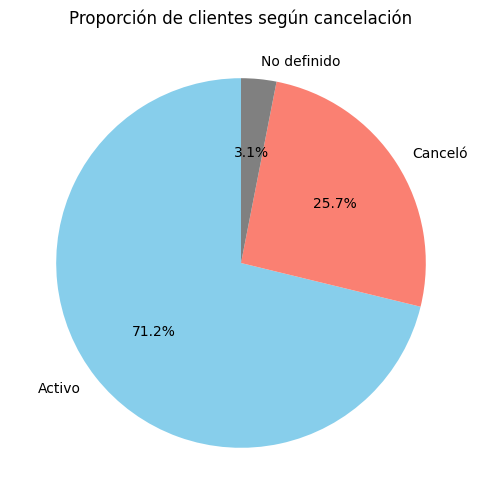

/tmp/ipykernel_236/3318247450.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_cancelacion.index, y=conteo_cancelacion.values, palette=['skyblue', 'salmon', 'gray'])


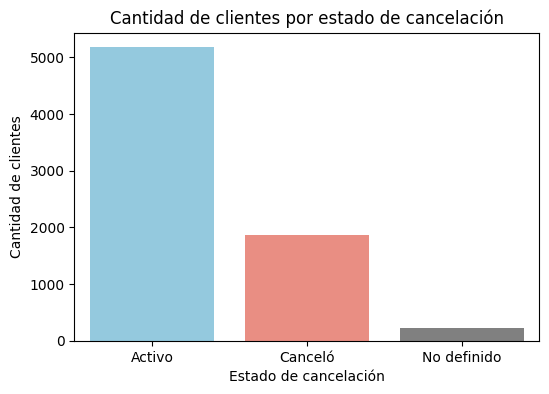

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapear valores numéricos a etiquetas
etiquetas = {0: "Activo", 1: "Canceló", -1: "No definido"}
conteo_cancelacion = df_expanded["cancelacion"].map(etiquetas).value_counts()

# Gráfico circular
plt.figure(figsize=(6, 6))
plt.pie(conteo_cancelacion, labels=conteo_cancelacion.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon', 'gray'])
plt.title("Proporción de clientes según cancelación")
plt.ylabel("")
plt.show()

# Gráfico de barras
plt.figure(figsize=(6, 4))
sns.barplot(x=conteo_cancelacion.index, y=conteo_cancelacion.values, palette=['skyblue', 'salmon', 'gray'])
plt.title("Cantidad de clientes por estado de cancelación")
plt.xlabel("Estado de cancelación")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

## Recuento de evasión por variables categóricas

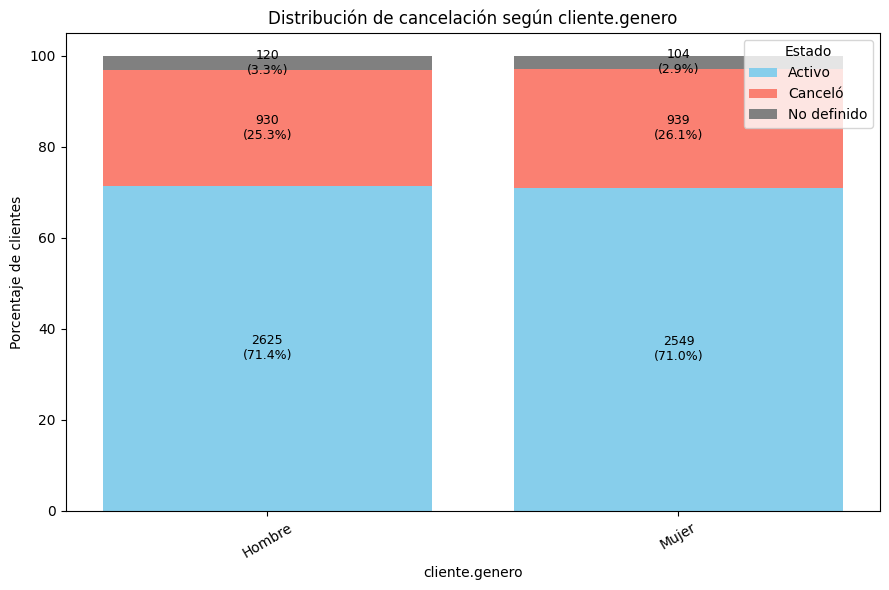

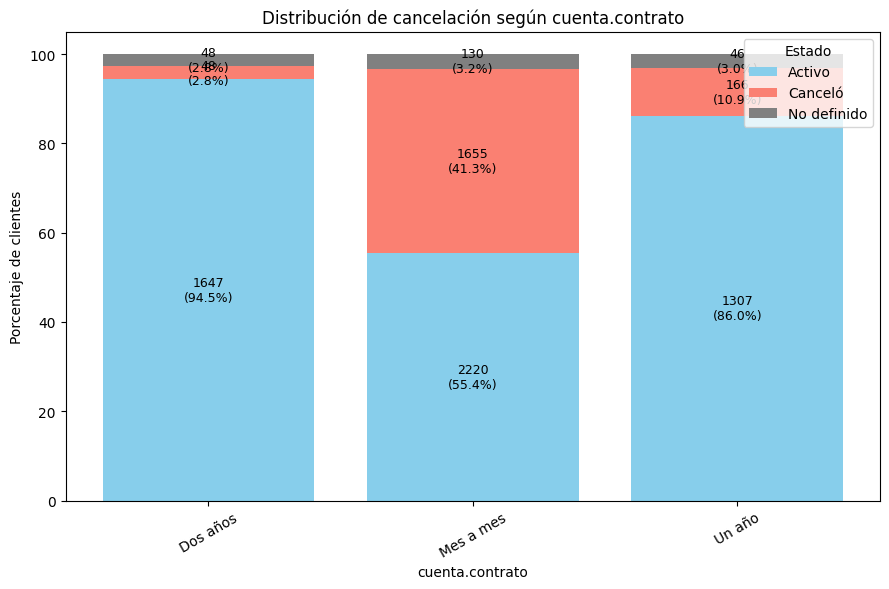

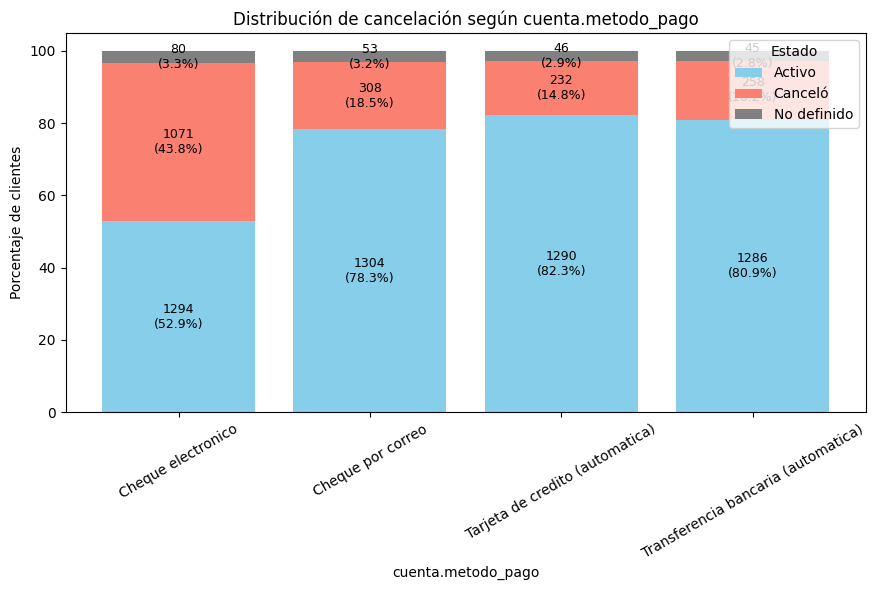

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Variables categóricas para el análisis de cancelación
categoricas = [
    "cliente.genero",
    "cuenta.contrato",
    "cuenta.metodo_pago"
]

# Reemplazar etiquetas de cancelación
etiquetas_cancelacion = {0: "Activo", 1: "Canceló", -1: "No definido"}

# Definir colores para los estados de cancelación
colors = {'Activo': 'skyblue', 'Canceló': 'salmon', 'No definido': 'gray'}
churn_states_sorted = ['Activo', 'Canceló', 'No definido'] # Para asegurar el orden de apilamiento y legend

for col in categoricas:
    fig, ax = plt.subplots(figsize=(9, 6))

    # Tabla cruzada con conteo absoluto
    conteo = pd.crosstab(
        df_expanded[col],
        df_expanded["cancelacion"].map(etiquetas_cancelacion)
    )

    # Tabla cruzada con porcentaje (normalizado por fila)
    porcentaje = pd.crosstab(
        df_expanded[col],
        df_expanded["cancelacion"].map(etiquetas_cancelacion),
        normalize="index"
    ) * 100

    bottom_val = np.zeros(len(porcentaje.index))

    # Crear las barras apiladas
    for estado in churn_states_sorted:
        if estado in porcentaje.columns:
            ax.bar(
                porcentaje.index,
                porcentaje[estado],
                bottom=bottom_val,
                label=estado,
                color=colors[estado]
            )
            bottom_val += porcentaje[estado]

    # Restablecer bottom_val para las etiquetas
    bottom_label = np.zeros(len(porcentaje.index))

    # Agregar etiquetas de número de clientes dentro de cada barra
    for i, categoria in enumerate(porcentaje.index):
        for estado in churn_states_sorted:
            if estado in porcentaje.columns:
                valor_abs = conteo.loc[categoria, estado]
                valor_pct = porcentaje.loc[categoria, estado]
                if valor_abs > 0:
                    ax.text(
                        i, bottom_label[i] + valor_pct / 2,
                        f"{valor_abs}\n({valor_pct:.1f}%)",
                        ha="center", va="center", fontsize=9, color="black"
                    )
                bottom_label[i] += valor_pct

    plt.title(f"Distribución de cancelación según {col}")
    plt.xlabel(col)
    plt.ylabel("Porcentaje de clientes")
    plt.legend(title="Estado", loc="upper right")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## Conteo de evasión por variables numéricas

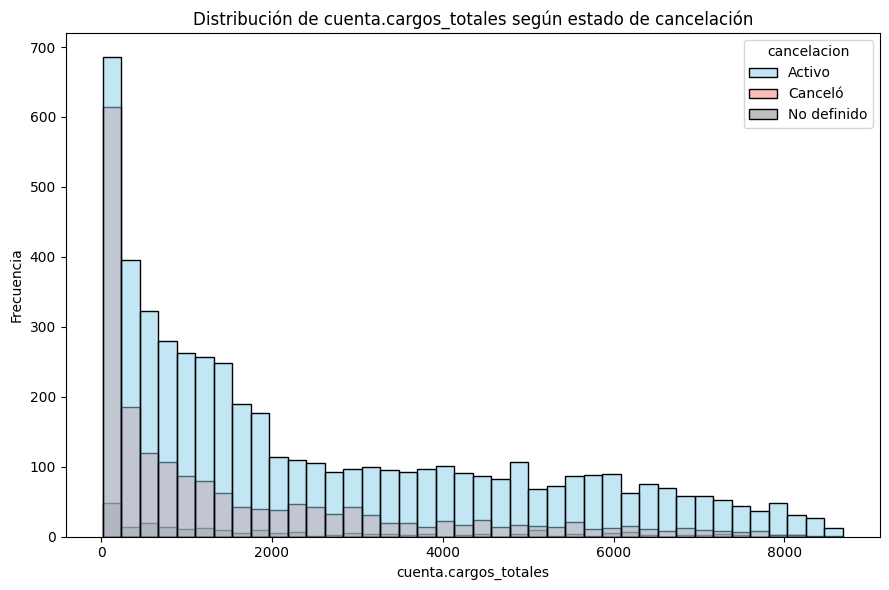

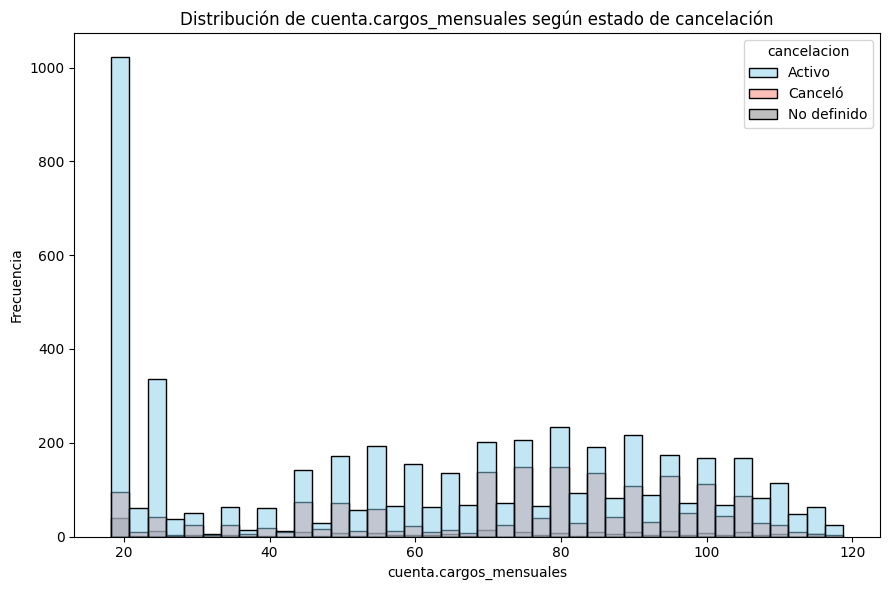

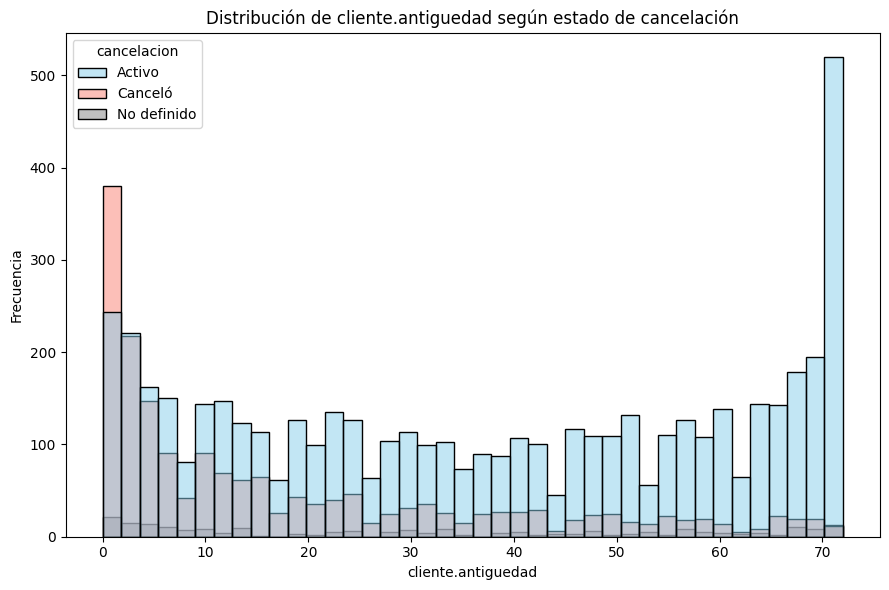

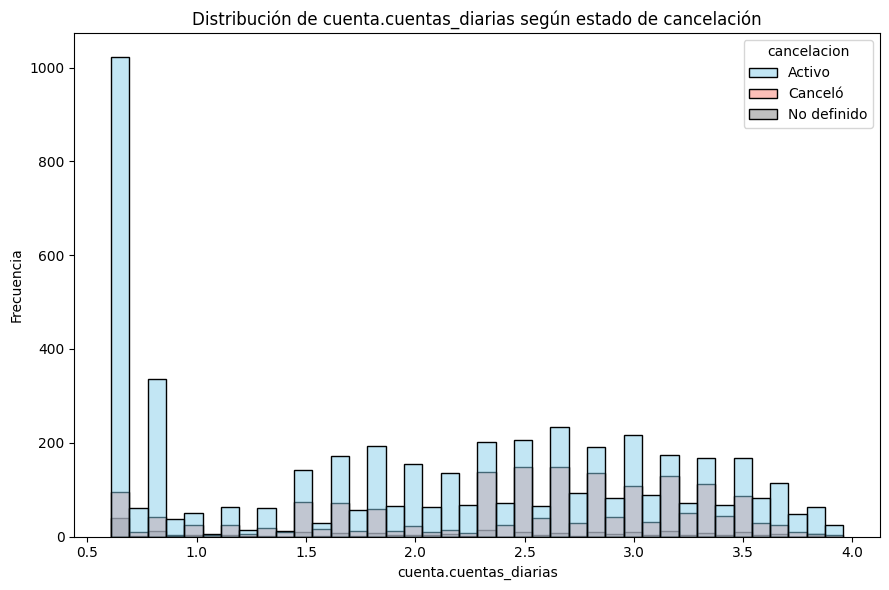

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

numericas = [
    "cuenta.cargos_totales",
    "cuenta.cargos_mensuales",
    "cliente.antiguedad",
    "cuenta.cuentas_diarias"
]

etiquetas_cancelacion = {0: "Activo", 1: "Canceló", -1: "No definido"}

for col in numericas:
    plt.figure(figsize=(9,6))
    sns.histplot(
        data=df_expanded,
        x=col,
        hue=df_expanded["cancelacion"].map(etiquetas_cancelacion),
        bins=40,
        palette={"Activo": "skyblue", "Canceló": "salmon", "No definido": "gray"}
    )
    plt.title(f"Distribución de {col} según estado de cancelación")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

In [45]:
# Asegurar que los cargos sean numéricos
df_expanded["cuenta.cargos_totales"] = pd.to_numeric(
    df_expanded["cuenta.cargos_totales"], errors="coerce"
)
df_expanded["cuenta.cargos_mensuales"] = pd.to_numeric(
    df_expanded["cuenta.cargos_mensuales"], errors="coerce"
)

# Mapear etiquetas legibles de cancelación
etiquetas_cancelacion = {0: "Activo", 1: "Canceló", -1: "No definido"}
# Crear una serie mapeada para usar en la agrupación
mapped_cancelacion = df_expanded["cancelacion"].map(etiquetas_cancelacion)

# Columnas numéricas relevantes
numericas = [
    "cuenta.cargos_totales",
    "cuenta.cargos_mensuales",
    "cliente.antiguedad",
    "cuenta.cuentas_diarias"
]

# Diccionario para almacenar los resultados de cada columna y estadística
all_stats_dfs = []

for col in numericas:
    # Calcular cada estadística por separado
    mean_s = df_expanded.groupby(mapped_cancelacion)[col].mean().rename('mean')
    median_s = df_expanded.groupby(mapped_cancelacion)[col].median().rename('median')
    std_s = df_expanded.groupby(mapped_cancelacion)[col].std().rename('std')
    min_s = df_expanded.groupby(mapped_cancelacion)[col].min().rename('min')
    max_s = df_expanded.groupby(mapped_cancelacion)[col].max().rename('max')

    # Unir las estadísticas para la columna actual en un DataFrame temporal
    col_stats_df = pd.concat([mean_s, median_s, std_s, min_s, max_s], axis=1).round(2)

    # Añadir un nivel de índice para el nombre de la columna numérica
    col_stats_df.columns = pd.MultiIndex.from_product([[col], col_stats_df.columns])
    all_stats_dfs.append(col_stats_df)

# Concatenar todos los DataFrames de estadísticas por columna
comparacion = pd.concat(all_stats_dfs, axis=1)

print(comparacion)

            cuenta.cargos_totales                                    \
                             mean   median      std    min      max   
cancelacion                                                           
Activo                    2555.34  1683.60  2329.46  18.80  8672.45   
Canceló                   1531.80   703.55  1890.82  18.85  8684.80   
No definido               2196.93  1163.18  2329.96  18.90  8425.30   

            cuenta.cargos_mensuales                               \
                               mean median    std    min     max   
cancelacion                                                        
Activo                        61.27  64.43  31.09  18.25  118.75   
Canceló                       74.44  79.65  24.67  18.85  118.35   
No definido                   63.41  69.10  31.39  18.75  115.55   

            cliente.antiguedad                       cuenta.cuentas_diarias  \
                          mean median    std min max                   mean   
cancel